# `HFSModel` with free noise tutorial

Trey V. Wenger (c) July 2026

Here we demonstrate how to use `HFSModel` when the spectral noise is unknown.

In [1]:
# General imports    
import time

import matplotlib.pyplot as plt
import arviz as az
import pandas as pd
import numpy as np
import pymc as pm

print("pymc version:", pm.__version__)
print("arviz version:", az.__version__)

import bayes_spec
print("bayes_spec version:", bayes_spec.__version__)

import bayes_hfs
print("bayes_hfs version:", bayes_hfs.__version__)

# Notebook configuration
pd.options.display.max_rows = None

/tmp/ipykernel_813411/3036834107.py:4: MatplotlibDeprecationWarning: The text.hinting_factor rcParam was deprecated in Matplotlib 3.11 and will be removed in 3.13.
  import matplotlib.pyplot as plt
/home/twenger/miniforge3/envs/bayes_hfs-dev2/lib/python3.14/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


pymc version: 5.28.5+1.gc9d1d93a0.dirty
arviz version: 0.23.4
bayes_spec version: 1.9.2+0.gb5cb650.dirty
bayes_hfs version: 1.1.4+0.ge580a19.dirty


## Preparing Molecule Data

In [2]:
from bayes_hfs import get_molecule_data, supplement_molecule_data
import pickle

try:
    all_mol_data_12CN, all_mol_metadata_12CN = get_molecule_data("CN, v=0,1", fmin=100.0, fmax=200.0)
    with open("mol_data_12CN.pkl", "wb") as f:
        pickle.dump(all_mol_data_12CN, f)
    with open("mol_metadata_12CN.pkl", "wb") as f:
        pickle.dump(all_mol_metadata_12CN, f)
except:
    with open("mol_data_12CN.pkl", "rb") as f:
        all_mol_data_12CN = pickle.load(f)
    with open("mol_metadata_12CN.pkl", "rb") as f:
        all_mol_metadata_12CN = pickle.load(f)

all_mol_data_12CN.pprint_all()

    FREQ     ERR    LGINT   DR    ELO    GUP MOLWT TAG  QNFMT  Ju  Ku  vu F1u F2u F3u  Jl  Kl  vl F1l F2l F3l    name    Lab 
    MHz      MHz   nm2 MHz       1 / cm        u                                                                             
----------- ------ ------- --- --------- --- ----- ---- ----- --- --- --- --- --- --- --- --- --- --- --- --- --------- -----
 112101.656   0.05 -8.0612   2 2042.4216   2    26 5041   234   1   1   1   1  --  --   0   1   1   2  --  -- CN, v=0,1  True
 112128.989   0.05  -8.069   2 2042.4222   4    26 5041   234   1   1   1   2  --  --   0   1   1   1  --  -- CN, v=0,1  True
 112148.503   0.05 -7.9593   2 2042.4216   4    26 5041   234   1   1   1   2  --  --   0   1   1   2  --  -- CN, v=0,1  True
 112442.806   0.05 -7.9569   2 2042.4222   4    26 5041   234   1   1   2   2  --  --   0   1   1   1  --  -- CN, v=0,1  True
 112445.015   0.05 -7.5311   2 2042.4216   6    26 5041   234   1   1   2   3  --  --   0   1   1   2  --  -- CN, v=0,

In [3]:
# Keep only Kl = 0 transitions
all_mol_data_12CN = all_mol_data_12CN[all_mol_data_12CN["Kl"] == 0]

# Add GLO
all_mol_data_12CN["GLO"] = 2 * all_mol_data_12CN["F1l"]

all_mol_data_12CN.pprint_all()

    FREQ     ERR    LGINT   DR  ELO   GUP MOLWT TAG  QNFMT  Ju  Ku  vu F1u F2u F3u  Jl  Kl  vl F1l F2l F3l    name    Lab  GLO
    MHz      MHz   nm2 MHz     1 / cm       u                                                                                 
----------- ------ ------- --- ------ --- ----- ---- ----- --- --- --- --- --- --- --- --- --- --- --- --- --------- ----- ---
113123.3701 0.0058 -4.7118   2 0.0007   2    26 5041   234   1   0   1   1  --  --   0   0   1   1  --  -- CN, v=0,1 False   2
113144.1573 0.0057 -3.7989   2   -0.0   2    26 5041   234   1   0   1   1  --  --   0   0   1   2  --  -- CN, v=0,1 False   4
113170.4915 0.0039  -3.809   2 0.0007   4    26 5041   234   1   0   1   2  --  --   0   0   1   1  --  -- CN, v=0,1 False   2
113191.2787 0.0034 -3.6955   2   -0.0   4    26 5041   234   1   0   1   2  --  --   0   0   1   2  --  -- CN, v=0,1 False   4
113488.1202 0.0033 -3.6932   2 0.0007   4    26 5041   234   1   0   2   2  --  --   0   0   1   1  --  -- CN, 

In [4]:
mol_data_12CN = supplement_molecule_data(all_mol_data_12CN, all_mol_metadata_12CN)
print(mol_data_12CN.keys())
print("molecular weight (Daltons):", mol_data_12CN['mol_weight'])
print("transition frequency (MHz):", mol_data_12CN['freq'])
print("Einstein A coefficient (s-1):", mol_data_12CN['Aul'])
print("Relative intensities:", mol_data_12CN['relative_int'])
print("state info:", mol_data_12CN["states"])
print("upper state index:", mol_data_12CN["state_u_idx"])
print("lower state index:", mol_data_12CN["state_l_idx"])
print("upper state degeneracy:", mol_data_12CN["Gu"])
print("lower state degeneracy:", mol_data_12CN["Gl"])

dict_keys(['mol_weight', 'freq', 'Aul', 'relative_int', 'states', 'state_u_idx', 'state_l_idx', 'Gu', 'Gl'])
molecular weight (Daltons): 26
transition frequency (MHz): [113123.3701 113144.1573 113170.4915 113191.2787 113488.1202 113490.9702
 113499.6443 113508.9074 113520.4315]
Einstein A coefficient (s-1): [1.24997446e-06 1.02301076e-05 4.99866053e-06 6.49280964e-06
 6.54458098e-06 1.15851092e-05 1.03265758e-05 5.04267116e-06
 1.26251089e-06]
Relative intensities: [0.01204927 0.09859632 0.09632981 0.12510097 0.12576526 0.33393404
 0.0992112  0.09688593 0.0121272 ]
state info: {'state': [np.str_('0 0 1 1 -- --'), np.str_('0 0 1 2 -- --'), np.str_('1 0 1 1 -- --'), np.str_('1 0 1 2 -- --'), np.str_('1 0 2 1 -- --'), np.str_('1 0 2 2 -- --'), np.str_('1 0 2 3 -- --')], 'deg': array([2, 4, 2, 4, 2, 4, 6]), 'E': array([ 1.00714381e-03, -0.00000000e+00,  5.43007265e+00,  5.43233412e+00,
        5.44813096e+00,  5.44757789e+00,  5.44670753e+00])}
upper state index: [2, 2, 3, 3, 5, 6, 4, 5, 4

## Simulating Data

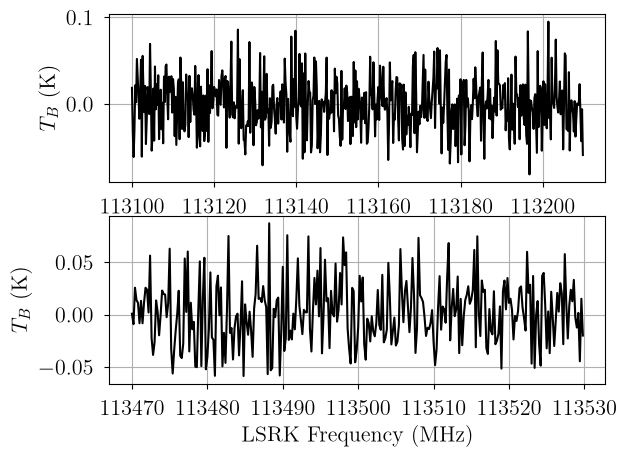

In [5]:
from bayes_spec import SpecData

# spectral axis definition
freq_axis_1 = np.arange(113100.0, 113210.0, 0.2) # MHz
freq_axis_2 = np.arange(113470.0, 113530.0, 0.2) # MHz

# data noise can either be a scalar (assumed constant noise across the spectrum)
# or an array of the same length as the data
noise = 0.03 # K

# brightness data. In this case, we just throw in some random data for now
# since we are only doing this in order to simulate some actual data.
brightness_data_1 = noise * np.random.randn(len(freq_axis_1)) # K
brightness_data_2 = noise * np.random.randn(len(freq_axis_2)) # K

# HFSModel datasets can be named anything, here we name them "12CN-1" and "12CN-2"
obs_1 = SpecData(
    freq_axis_1,
    brightness_data_1,
    noise,
    xlabel=r"LSRK Frequency (MHz)",
    ylabel=r"$T_B$ (K)",
)
obs_2 = SpecData(
    freq_axis_2,
    brightness_data_2,
    noise,
    xlabel=r"LSRK Frequency (MHz)",
    ylabel=r"$T_B$ (K)",
)
dummy_data = {"12CN-1": obs_1, "12CN-2": obs_2}

# Plot the simulated data
fig, axes = plt.subplots(2)
axes[0].plot(dummy_data["12CN-1"].spectral, dummy_data["12CN-1"].brightness, "k-")
axes[0].set_ylabel(dummy_data["12CN-1"].ylabel)
axes[1].plot(dummy_data["12CN-2"].spectral, dummy_data["12CN-2"].brightness, "k-")
axes[1].set_xlabel(dummy_data["12CN-2"].xlabel)
_ = axes[1].set_ylabel(dummy_data["12CN-2"].ylabel)

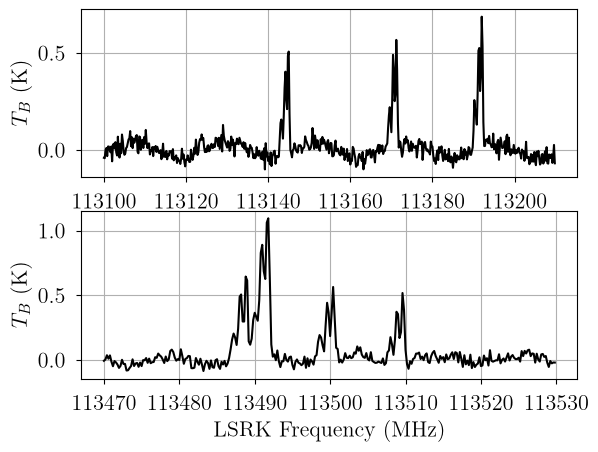

In [9]:
from bayes_hfs import HFSModel

# Initialize and define the model
n_clouds = 3 # number of cloud components
baseline_degree = 0 # polynomial baseline degree
model = HFSModel(
    mol_data_12CN, # molecular data
    dummy_data,
    bg_temp = 2.7, # assumed background temperature (K)
    Beff = 1.0, # beam efficiency
    Feff = 1.0, # forward efficiency
    n_clouds=n_clouds,
    baseline_degree=baseline_degree,
    ripples=True,
    seed=1234,
    verbose=True
)
model.add_priors(
    prior_log10_Ntot = [13.5, 0.5], # mean and width of log10 total column density prior (cm-2)
    prior_fwhm2 = 1.0, # width of FWHM^2 prior (km2 s-2)
    prior_velocity = [-3.0, 3.0], # upper and lower limit of velocity prior (km/s)
    prior_log10_Tex_CTEX = [0.75, 0.25], # mean and width of log10 CTEX excitation temperature prior (K)
    assume_CTEX = True, # assume CTEX
    prior_log10_CTEX_variance = None, # ignored because CTEX
    clip_weights = 1.0e-9, # clip statistical weights between [clip_weights, 1-clip_weights]
    clip_tau = -10.0, # clip optical depths below to prevent masers
    prior_fwhm_L = None, # assume Gaussian line profile
    prior_baseline_coeffs = None, # use default baseline priors
    prior_ripple_amplitude = None, # use default ripple amplitude priors
    prior_ripple_wavenumber = None, # use default ripple wavenumber priors
    prior_noise = {"12CN-1": 0.1, "12CN-2": 0.1}, # width of spectral noise prior (K)
)
model.add_likelihood()

sim_params = {
    "log10_Ntot": np.array([13.8, 13.9, 14.0]),
    "fwhm2": np.array([1.0, 1.25, 1.5])**2.0,
    "velocity": [-2.0, 0.0, 2.5],
    "log10_Tex_CTEX": np.log10([4.46, 3.98, 3.16]),
    "baseline_12CN-1_norm": [0.0],
    "baseline_12CN-2_norm": [0.0],
    "ripple_12CN-1_amplitude_norm": 1.0,
    "ripple_12CN-2_amplitude_norm": 1.0,
    "ripple_12CN-1_wavenumber": 5.0,
    "ripple_12CN-2_wavenumber": 5.0,
    "ripple_12CN-1_phase_norm": -np.pi/2.0,
    "ripple_12CN-2_phase_norm": np.pi/2.0,
    "noise_12CN-1": noise,
    "noise_12CN-2": noise,
}

# add derived quantities to sim_params
for key in model.cloud_deterministics:
    if key not in sim_params.keys():
        sim_params[key] = model.model[key].eval(sim_params, on_unused_input="ignore")

# Evaluate and save simulated observations
sim_obs1 = model.model["12CN-1"].eval(sim_params, on_unused_input="ignore")
sim_obs2 = model.model["12CN-2"].eval(sim_params, on_unused_input="ignore")

# Plot the simulated data
fig, axes = plt.subplots(2)
axes[0].plot(dummy_data["12CN-1"].spectral, sim_obs1, "k-")
axes[0].set_ylabel(dummy_data["12CN-1"].ylabel)
axes[1].plot(dummy_data["12CN-2"].spectral, sim_obs2, "k-")
axes[1].set_xlabel(dummy_data["12CN-2"].xlabel)
_ = axes[1].set_ylabel(dummy_data["12CN-2"].ylabel)

In [10]:
sim_params

{'log10_Ntot': array([13.8, 13.9, 14. ]),
 'fwhm2': array([1.    , 1.5625, 2.25  ]),
 'velocity': [-2.0, 0.0, 2.5],
 'log10_Tex_CTEX': array([0.64933486, 0.59988307, 0.49968708]),
 'baseline_12CN-1_norm': [0.0],
 'baseline_12CN-2_norm': [0.0],
 'ripple_12CN-1_amplitude_norm': 1.0,
 'ripple_12CN-2_amplitude_norm': 1.0,
 'ripple_12CN-1_wavenumber': 5.0,
 'ripple_12CN-2_wavenumber': 5.0,
 'ripple_12CN-1_phase_norm': -1.5707963267948966,
 'ripple_12CN-2_phase_norm': 1.5707963267948966,
 'noise_12CN-1': 0.03,
 'noise_12CN-2': 0.03,
 'CTEX_weights': array([[1.99954842, 4.        , 0.59193533, 1.18327051, 0.58954346,
         1.17923313, 1.76919492],
        [1.99949396, 4.        , 0.51109864, 1.02161662, 0.5087849 ,
         1.01771121, 1.52690069],
        [1.99936267, 4.        , 0.35871387, 0.71691448, 0.35666979,
         0.71346443, 1.07049146]]),
 'Tex': array([4.46, 3.98, 3.16]),
 'tau': array([[0.02742294, 0.03901221, 0.06218552],
        [0.22442582, 0.31927704, 0.50895265],
      

In [11]:
# Now we pack the simulated spectrum into a new SpecData instance
obs_1 = SpecData(
    freq_axis_1,
    sim_obs1,
    noise,
    xlabel=r"LSRK Frequency (MHz)",
    ylabel=r"$T_B$ (K)",
)
obs_2 = SpecData(
    freq_axis_2,
    sim_obs2,
    noise,
    xlabel=r"LSRK Frequency (MHz)",
    ylabel=r"$T_B$ (K)",
)
data = {"12CN-1": obs_1, "12CN-2": obs_2}

## Model Definition

In [12]:
# Initialize and define the model
model = HFSModel(
    mol_data_12CN, # molecular data
    data,
    bg_temp = 2.7, # assumed background temperature (K)
    Beff = 1.0, # beam efficiency
    Feff = 1.0, # forward efficiency
    n_clouds=n_clouds,
    baseline_degree=baseline_degree,
    ripples=True,
    seed=1234,
    verbose=True
)
model.add_priors(
    prior_log10_Ntot = [13.5, 0.5], # mean and width of log10 total column density prior (cm-2)
    prior_fwhm2 = 1.0, # width of FWHM^2 prior (km2 s-2)
    prior_velocity = [-3.0, 3.0], # upper and lower limit of velocity prior (km/s)
    prior_log10_Tex_CTEX = [0.75, 0.25], # mean and width of log10 CTEX excitation temperature prior (K)
    assume_CTEX = True, # assume CTEX
    prior_log10_CTEX_variance = None, # ignored because CTEX
    clip_weights = 1.0e-9, # clip statistical weights between [clip_weights, 1-clip_weights]
    clip_tau = -10.0, # clip optical depths below to prevent masers
    prior_fwhm_L = None, # assume Gaussian line profile
    prior_baseline_coeffs = None, # use default baseline priors
    prior_ripple_amplitude = None, # use default ripple amplitude priors
    prior_ripple_wavenumber = None, # use default ripple wavenumber priors
    prior_noise = {"12CN-1": 0.1, "12CN-2": 0.1}, # width of spectral noise prior (K)
)
model.add_likelihood()

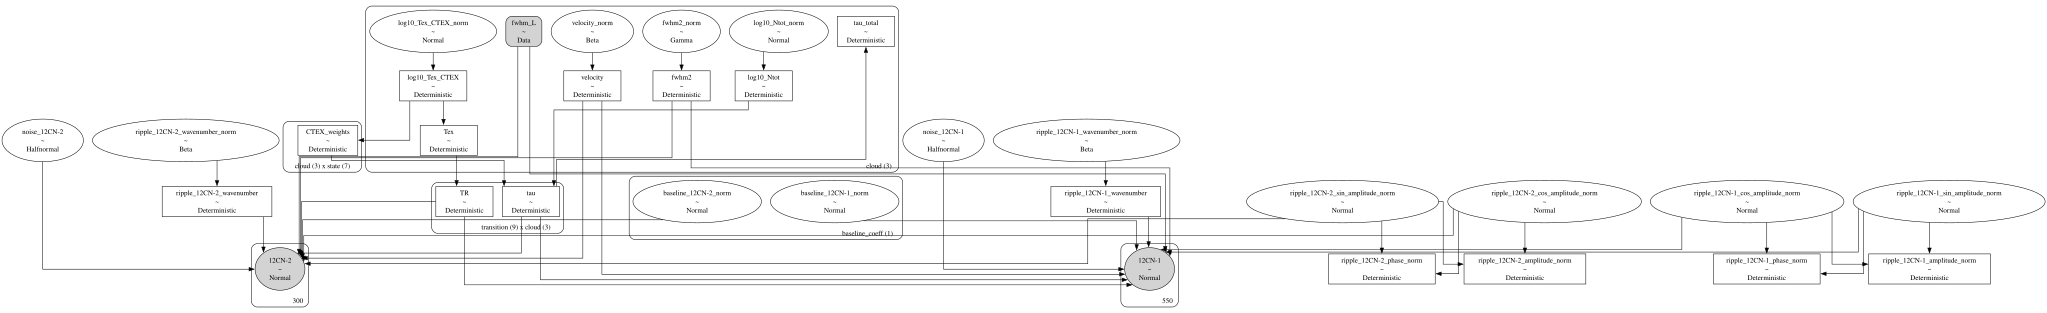

In [13]:
# Plot model graph
model.graph().render('hfs_model', format='png')
model.graph()

In [14]:
# model string representation
print(model.model.str_repr())

            baseline_12CN-1_norm ~ Normal(0, 1)
            baseline_12CN-2_norm ~ Normal(0, 1)
ripple_12CN-1_cos_amplitude_norm ~ Normal(0, 0.707)
ripple_12CN-1_sin_amplitude_norm ~ Normal(0, 0.707)
   ripple_12CN-1_wavenumber_norm ~ Beta(2, 2)
ripple_12CN-2_cos_amplitude_norm ~ Normal(0, 0.707)
ripple_12CN-2_sin_amplitude_norm ~ Normal(0, 0.707)
   ripple_12CN-2_wavenumber_norm ~ Beta(2, 2)
                 log10_Ntot_norm ~ Normal(0, 1)
                      fwhm2_norm ~ Gamma(0.5, f())
                   velocity_norm ~ Beta(2, 2)
             log10_Tex_CTEX_norm ~ Normal(0, 1)
                    noise_12CN-1 ~ HalfNormal(0, 0.1)
                    noise_12CN-2 ~ HalfNormal(0, 0.1)
        ripple_12CN-1_wavenumber ~ Deterministic(f(ripple_12CN-1_wavenumber_norm))
    ripple_12CN-1_amplitude_norm ~ Deterministic(f(ripple_12CN-1_sin_amplitude_norm, ripple_12CN-1_cos_amplitude_norm))
        ripple_12CN-1_phase_norm ~ Deterministic(f(ripple_12CN-1_sin_amplitude_norm, ripple_12CN-1_c

Sampling: [12CN-1, 12CN-2, baseline_12CN-1_norm, baseline_12CN-2_norm, fwhm2_norm, log10_Ntot_norm, log10_Tex_CTEX_norm, noise_12CN-1, noise_12CN-2, ripple_12CN-1_cos_amplitude_norm, ripple_12CN-1_sin_amplitude_norm, ripple_12CN-1_wavenumber_norm, ripple_12CN-2_cos_amplitude_norm, ripple_12CN-2_sin_amplitude_norm, ripple_12CN-2_wavenumber_norm, velocity_norm]


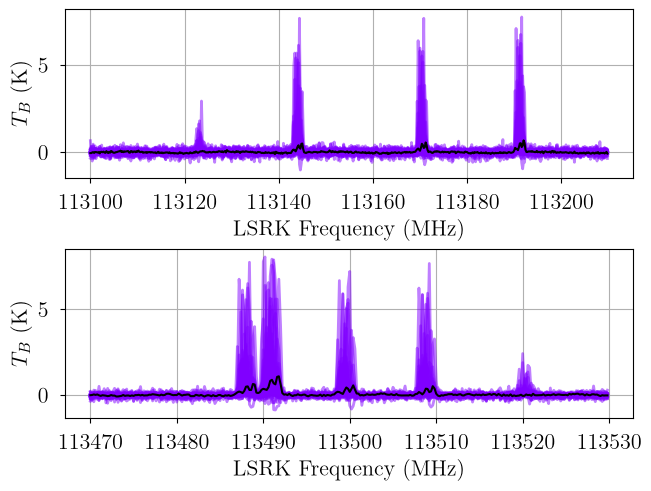

In [15]:
from bayes_spec.plots import plot_predictive

# prior predictive check
prior = model.sample_prior_predictive(
    samples=1000,  # prior predictive samples
)
_ = plot_predictive(model.data, prior.prior_predictive.sel(draw=slice(None, None, 20)))

In [16]:
model.model.initial_point()

{'baseline_12CN-1_norm': array([0.]),
 'baseline_12CN-2_norm': array([0.]),
 'ripple_12CN-1_cos_amplitude_norm': array(0.),
 'ripple_12CN-1_sin_amplitude_norm': array(0.),
 'ripple_12CN-1_wavenumber_norm_logodds__': array(0.),
 'ripple_12CN-2_cos_amplitude_norm': array(0.),
 'ripple_12CN-2_sin_amplitude_norm': array(0.),
 'ripple_12CN-2_wavenumber_norm_logodds__': array(0.),
 'log10_Ntot_norm': array([0., 0., 0.]),
 'fwhm2_norm_log__': array([0., 0., 0.]),
 'velocity_norm_logodds__': array([0., 0., 0.]),
 'log10_Tex_CTEX_norm': array([0., 0., 0.]),
 'noise_12CN-1_log__': array(-2.30258509),
 'noise_12CN-2_log__': array(-2.30258509)}

In [17]:
print(model.cloud_freeRVs)
print(model.cloud_deterministics)

['log10_Ntot_norm', 'fwhm2_norm', 'velocity_norm', 'log10_Tex_CTEX_norm']
['log10_Ntot', 'fwhm2', 'velocity', 'log10_Tex_CTEX', 'CTEX_weights', 'Tex', 'tau', 'tau_total', 'TR']


['log10_Ntot', 'fwhm2', 'velocity', 'log10_Tex_CTEX', 'Tex', 'tau_total']


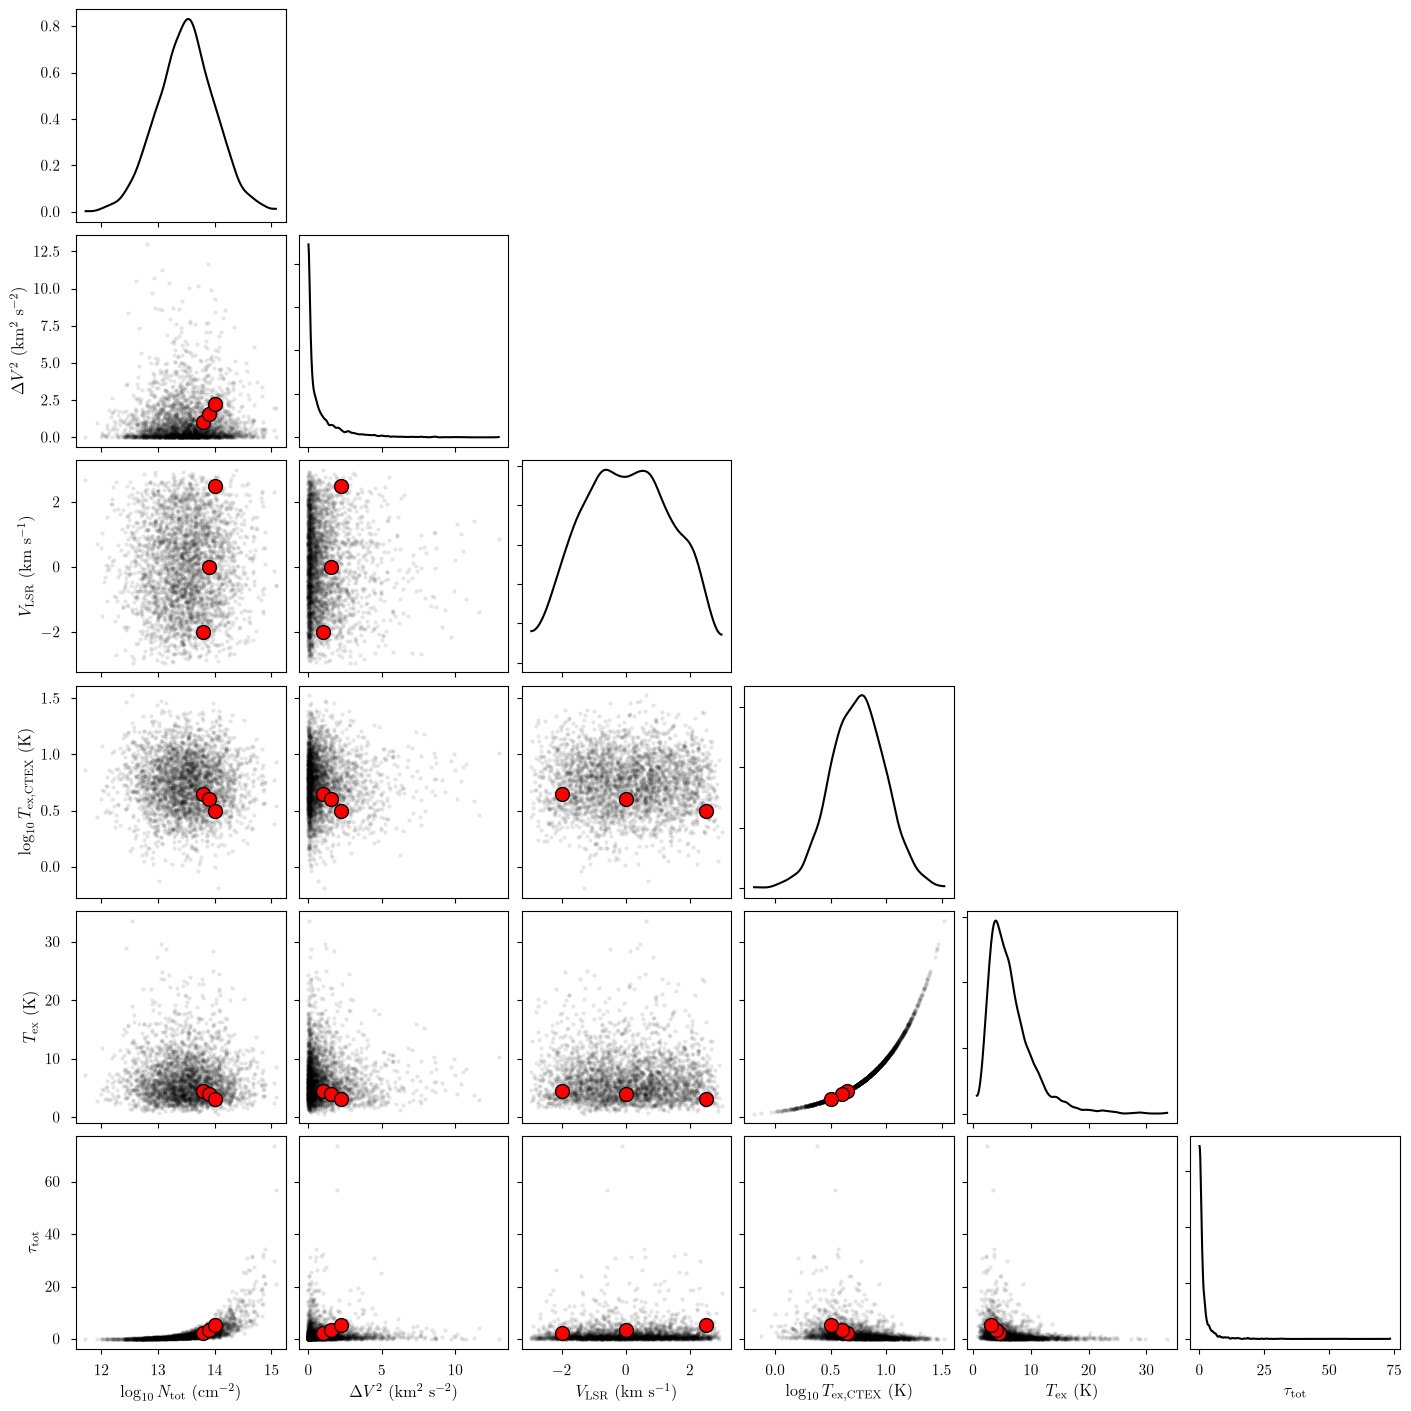

In [18]:
from bayes_spec.plots import plot_pair

var_names = [
    param for param in model.cloud_deterministics + [p for p in model.cloud_freeRVs if "_norm" not in p]
    if not set(model.model.named_vars_to_dims[param]).intersection(set(["transition", "state"]))
]
print(var_names)
_ = plot_pair(
    prior.prior, # samples
    var_names, # var_names to plot
    combine_dims=["cloud"], # concatenate clouds
    labeller=model.labeller, # label manager
    kind="scatter", # plot type
    reference_values=sim_params, # truths
)

## Variational Inference

In [19]:
start = time.time()
model.fit(
    n = 1_000_000, # maximum number of VI iterations
    draws = 1_000, # number of posterior samples
    rel_tolerance = 0.01, # VI relative convergence threshold
    abs_tolerance = 0.01, # VI absolute convergence threshold
    learning_rate = 0.001, # VI learning rate
    start = {"velocity_norm": np.linspace(0.1, 0.9, model.n_clouds)},
)
end = time.time()
print(f"Runtime: {(end-start)/60.0:.2f} minutes")

ERROR (pytensor.graph.rewriting.basic): SequentialGraphRewriter apply <pytensor.tensor.rewriting.elemwise.FusionOptimizer object at 0x76cc6d8c9be0>
ERROR (pytensor.graph.rewriting.basic): Traceback:
ERROR (pytensor.graph.rewriting.basic): Traceback (most recent call last):
  File "/home/twenger/miniforge3/envs/bayes_hfs-dev2/lib/python3.14/site-packages/pytensor/graph/rewriting/basic.py", line 289, in apply
    sub_prof = rewriter.apply(fgraph)
  File "/home/twenger/miniforge3/envs/bayes_hfs-dev2/lib/python3.14/site-packages/pytensor/tensor/rewriting/elemwise.py", line 886, in apply
    scalar_inputs, scalar_outputs = self.elemwise_to_scalar(inputs, outputs)
                                    ~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "/home/twenger/miniforge3/envs/bayes_hfs-dev2/lib/python3.14/site-packages/pytensor/tensor/rewriting/elemwise.py", line 543, in elemwise_to_scalar
    node.op.scalar_op.make_node(*scalar_inputs).outputs,
    ^^^^^^^^^^^^^^^^^
AttributeError: 'DimShu

Output()

Convergence achieved at 27000
Interrupted at 26,999 [2%]: Average Loss = -1,371.7


Adding log-likelihood to trace


Output()

Runtime: 5.80 minutes


In [20]:
pm.summary(model.trace.posterior)

arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)
/home/twenger/miniforge3/envs/bayes_hfs-dev2/lib/python3.14/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4
/home/twenger/miniforge3/envs/bayes_hfs-dev2/lib/python3.14/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4
/home/twenger/miniforge3/envs/bayes_hfs-dev2/lib/python3.14/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
baseline_12CN-1_norm[0],-0.041,0.039,-0.119,0.031,0.001,0.001,961.0,921.0,NaN
baseline_12CN-2_norm[0],-0.005,0.057,-0.101,0.104,0.002,0.001,1036.0,1026.0,NaN
ripple_12CN-1_cos_amplitude_norm,0.690,0.054,0.580,0.786,0.002,0.001,974.0,900.0,NaN
ripple_12CN-1_sin_amplitude_norm,-1.084,0.056,-1.189,-0.982,0.002,0.001,947.0,737.0,NaN
ripple_12CN-2_cos_amplitude_norm,0.159,0.080,0.016,0.307,0.003,0.002,956.0,742.0,NaN
ripple_12CN-2_sin_amplitude_norm,1.166,0.083,1.016,1.320,0.003,0.002,1029.0,779.0,NaN
log10_Ntot_norm[0],0.647,0.014,0.618,0.671,0.000,0.000,966.0,943.0,NaN
log10_Ntot_norm[1],0.799,0.017,0.768,0.831,0.001,0.000,1077.0,982.0,NaN
log10_Ntot_norm[2],0.987,0.040,0.920,1.067,0.001,0.001,895.0,832.0,NaN
log10_Tex_CTEX_norm[0],-0.450,0.009,-0.466,-0.433,0.000,0.000,946.0,876.0,NaN


Sampling: [12CN-1, 12CN-2]


Output()

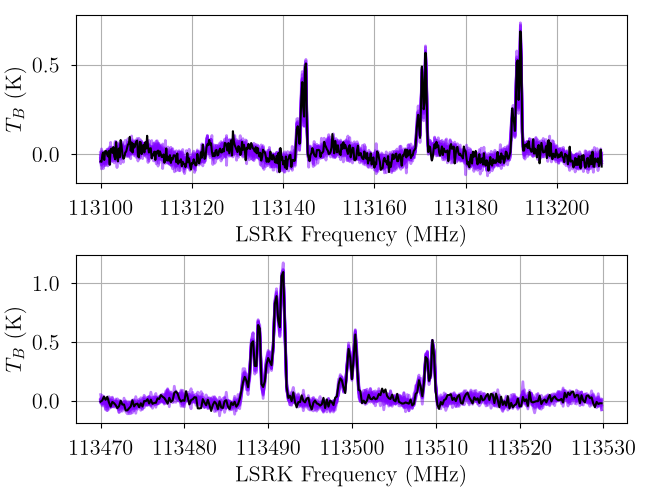

In [21]:
posterior = model.sample_posterior_predictive(
    thin=100, # keep one in {thin} posterior samples
)
_ = plot_predictive(model.data, posterior.posterior_predictive)

## Posterior Sampling: MCMC

In [22]:
start = time.time()
model.sample(
    init="advi+adapt_diag",  # initialization strategy
    tune=1000,  # tuning samples
    draws=1000,  # posterior samples
    chains=8,  # number of independent chains
    cores=8,  # number of parallel chains
    init_kwargs={
        "rel_tolerance": 0.01,
        "abs_tolerance": 0.01,
        "learning_rate": 0.001,
        "start": {"velocity_norm": np.linspace(0.1, 0.9, model.n_clouds)},
    },  # VI initialization arguments
    nuts_kwargs={"target_accept": 0.8},  # NUTS arguments
)
end = time.time()
print(f"Runtime: {(end-start)/60.0:.2f} minutes")

Initializing NUTS using custom advi+adapt_diag strategy


ERROR (pytensor.graph.rewriting.basic): SequentialGraphRewriter apply <pytensor.tensor.rewriting.elemwise.FusionOptimizer object at 0x76cc6d8c9be0>
ERROR (pytensor.graph.rewriting.basic): Traceback:
ERROR (pytensor.graph.rewriting.basic): Traceback (most recent call last):
  File "/home/twenger/miniforge3/envs/bayes_hfs-dev2/lib/python3.14/site-packages/pytensor/graph/rewriting/basic.py", line 289, in apply
    sub_prof = rewriter.apply(fgraph)
  File "/home/twenger/miniforge3/envs/bayes_hfs-dev2/lib/python3.14/site-packages/pytensor/tensor/rewriting/elemwise.py", line 886, in apply
    scalar_inputs, scalar_outputs = self.elemwise_to_scalar(inputs, outputs)
                                    ~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "/home/twenger/miniforge3/envs/bayes_hfs-dev2/lib/python3.14/site-packages/pytensor/tensor/rewriting/elemwise.py", line 543, in elemwise_to_scalar
    node.op.scalar_op.make_node(*scalar_inputs).outputs,
    ^^^^^^^^^^^^^^^^^
AttributeError: 'DimShu

Output()

Convergence achieved at 27000
Interrupted at 26,999 [2%]: Average Loss = -1,371.7
Multiprocess sampling (8 chains in 8 jobs)
NUTS: [baseline_12CN-1_norm, baseline_12CN-2_norm, ripple_12CN-1_cos_amplitude_norm, ripple_12CN-1_sin_amplitude_norm, ripple_12CN-1_wavenumber_norm, ripple_12CN-2_cos_amplitude_norm, ripple_12CN-2_sin_amplitude_norm, ripple_12CN-2_wavenumber_norm, log10_Ntot_norm, fwhm2_norm, velocity_norm, log10_Tex_CTEX_norm, noise_12CN-1, noise_12CN-2]


Output()

Sampling 8 chains for 1_000 tune and 1_000 draw iterations (8_000 + 8_000 draws total) took 125 seconds.


Adding log-likelihood to trace


Output()

Runtime: 7.92 minutes


In [23]:
model.solve(
    init_params="random_from_data", # GMM initialization strategy
    n_init=10, # number of GMM initilizations
    max_iter=1_000, # maximum number of GMM iterations
    kl_div_threshold=0.1, # covergence threshold
)

GMM converged to unique solution


In [24]:
print("solutions:", model.solutions)
az.summary(model.trace.solution_0)
# this also works: az.summary(model.trace.solution_0)

solutions: [0]


/home/twenger/miniforge3/envs/bayes_hfs-dev2/lib/python3.14/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/home/twenger/miniforge3/envs/bayes_hfs-dev2/lib/python3.14/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4
/home/twenger/miniforge3/envs/bayes_hfs-dev2/lib/python3.14/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/home/twenger/miniforge3/envs/bayes_hfs-dev2/lib/python3.14/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4
/home/twenger/miniforge3/envs/bayes_hfs-dev2/lib/python3.14/site-packages/arviz/stats/diagnostics.py:596: RuntimeW

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
baseline_12CN-1_norm[0],-0.043,0.039,-0.117,0.028,0.000,0.000,13959.0,5750.0,1.0
baseline_12CN-2_norm[0],-0.006,0.061,-0.117,0.109,0.001,0.001,14715.0,6039.0,1.0
ripple_12CN-1_cos_amplitude_norm,0.694,0.055,0.591,0.798,0.000,0.001,13910.0,5628.0,1.0
ripple_12CN-1_sin_amplitude_norm,-1.081,0.054,-1.180,-0.979,0.000,0.001,14272.0,5793.0,1.0
ripple_12CN-2_cos_amplitude_norm,0.157,0.083,0.006,0.316,0.001,0.001,16259.0,6024.0,1.0
ripple_12CN-2_sin_amplitude_norm,1.173,0.085,1.012,1.332,0.001,0.001,11928.0,6302.0,1.0
log10_Ntot_norm[0],0.647,0.043,0.567,0.728,0.001,0.000,6784.0,5845.0,1.0
log10_Ntot_norm[1],0.799,0.052,0.698,0.894,0.001,0.001,6709.0,5435.0,1.0
log10_Ntot_norm[2],1.014,0.121,0.789,1.240,0.002,0.001,6416.0,5373.0,1.0
log10_Tex_CTEX_norm[0],-0.448,0.028,-0.497,-0.394,0.000,0.000,6890.0,5981.0,1.0


Sampling: [12CN-1, 12CN-2]


Output()

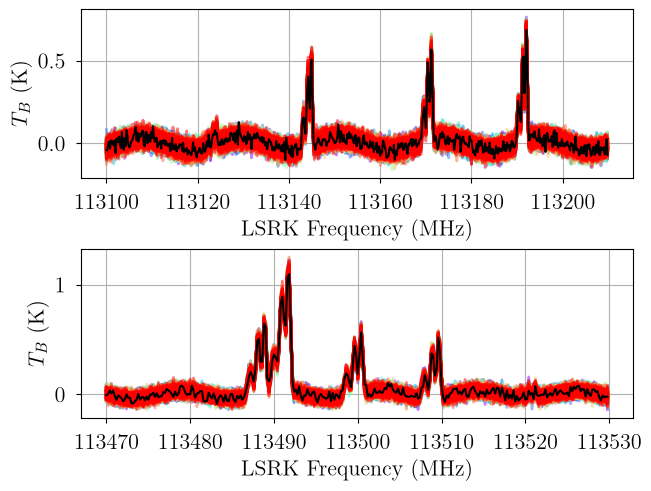

In [40]:
posterior = model.sample_posterior_predictive(
    thin=10, # keep one in {thin} posterior samples
)
_ = plot_predictive(model.data, posterior.posterior_predictive)

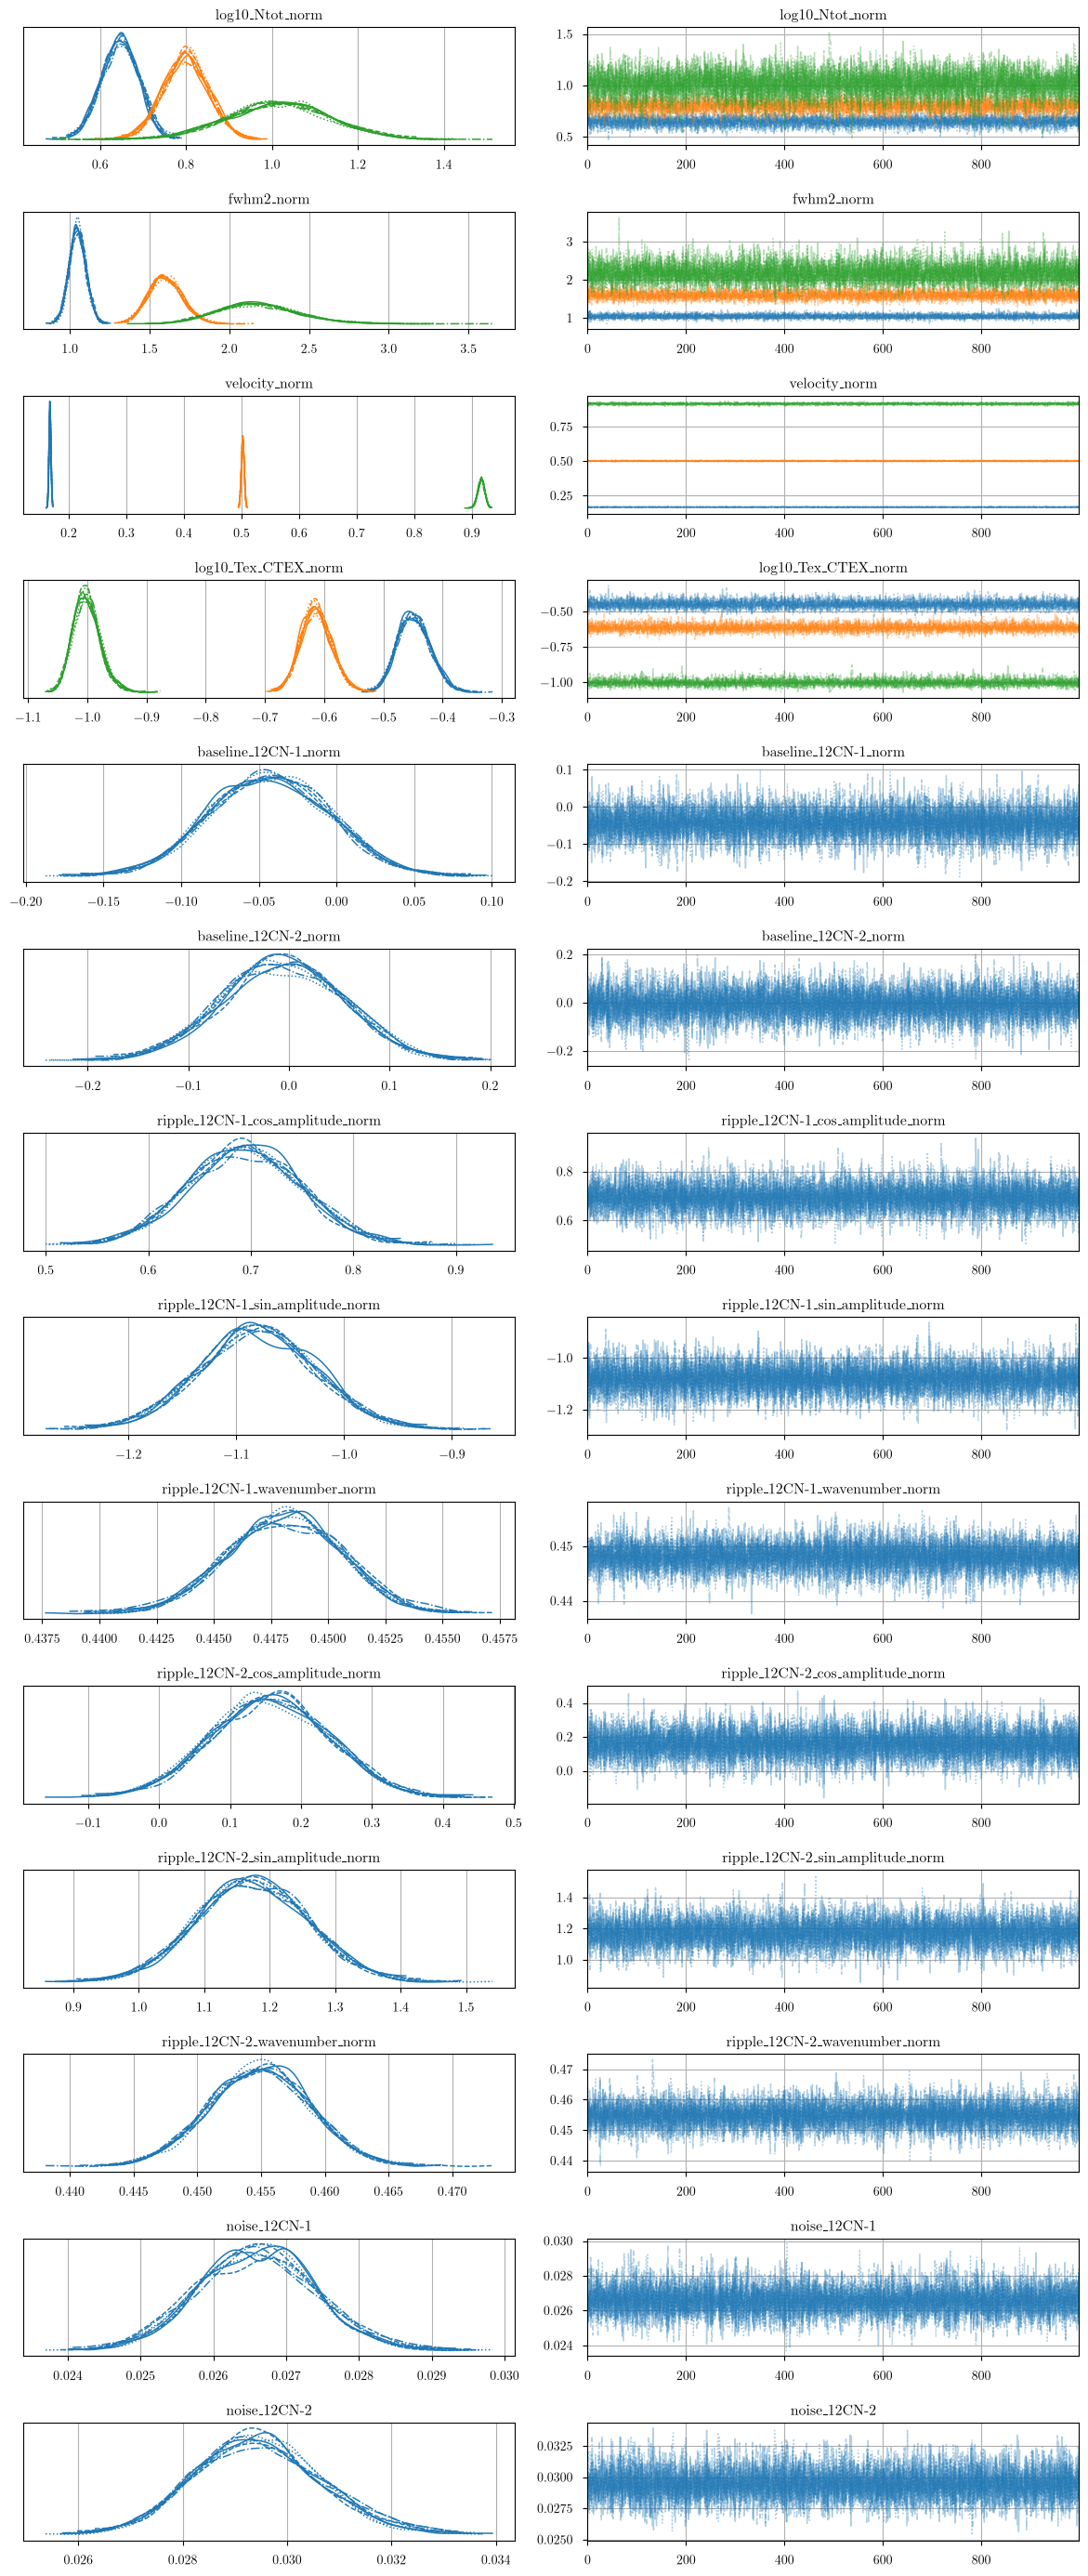

In [26]:
from bayes_spec.plots import plot_traces

axes = plot_traces(model.trace.solution_0, model.cloud_freeRVs + model.baseline_freeRVs + model.hyper_freeRVs)
fig = axes.ravel()[0].figure
fig.tight_layout()

['log10_Ntot_norm', 'fwhm2_norm', 'velocity_norm', 'log10_Tex_CTEX_norm']


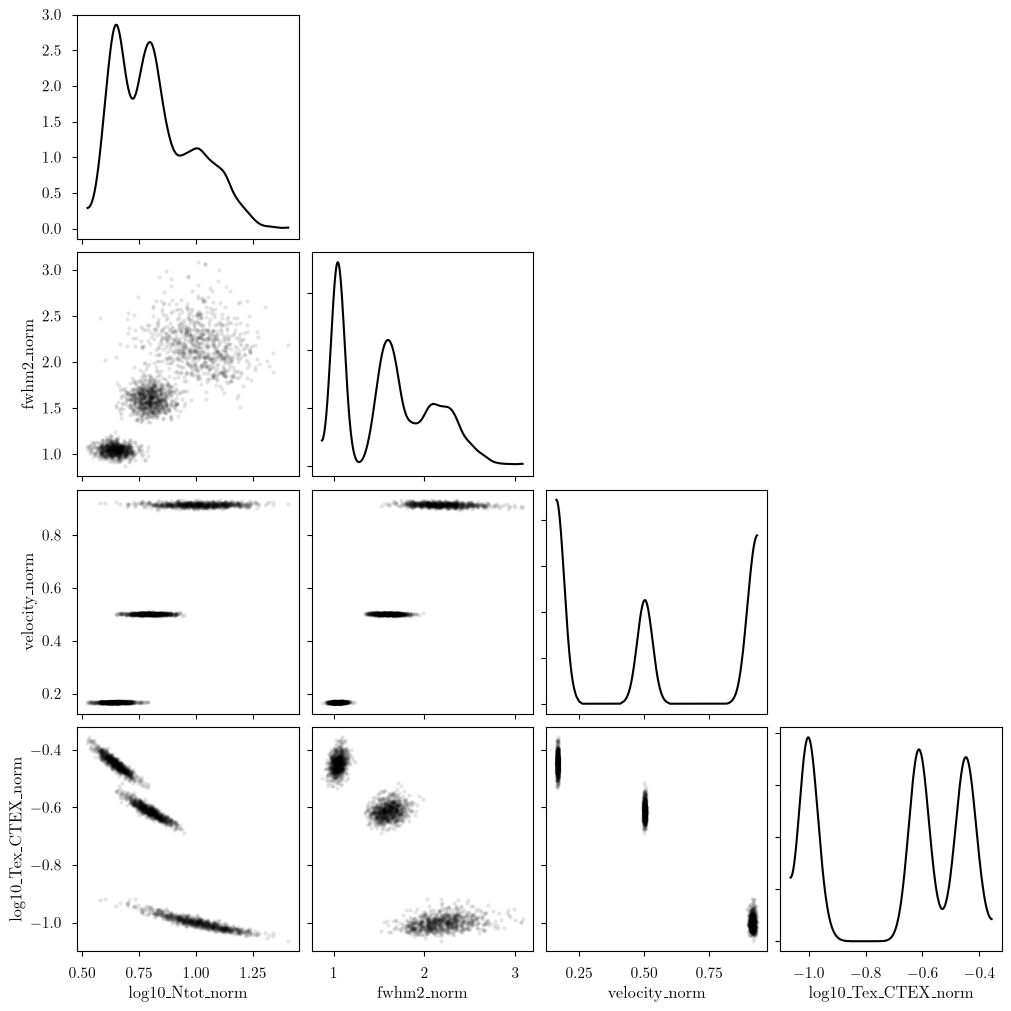

In [27]:
var_names = [
    param for param in model.cloud_freeRVs
    if not set(model.model.named_vars_to_dims[param]).intersection(set(["transition", "state"]))
]
print(var_names)
_ = plot_pair(
    model.trace.solution_0.sel(draw=slice(None, None, 10)), # samples
    var_names, # var_names to plot
    combine_dims=["cloud"], # concatenate clouds
    kind="scatter", # plot type
)

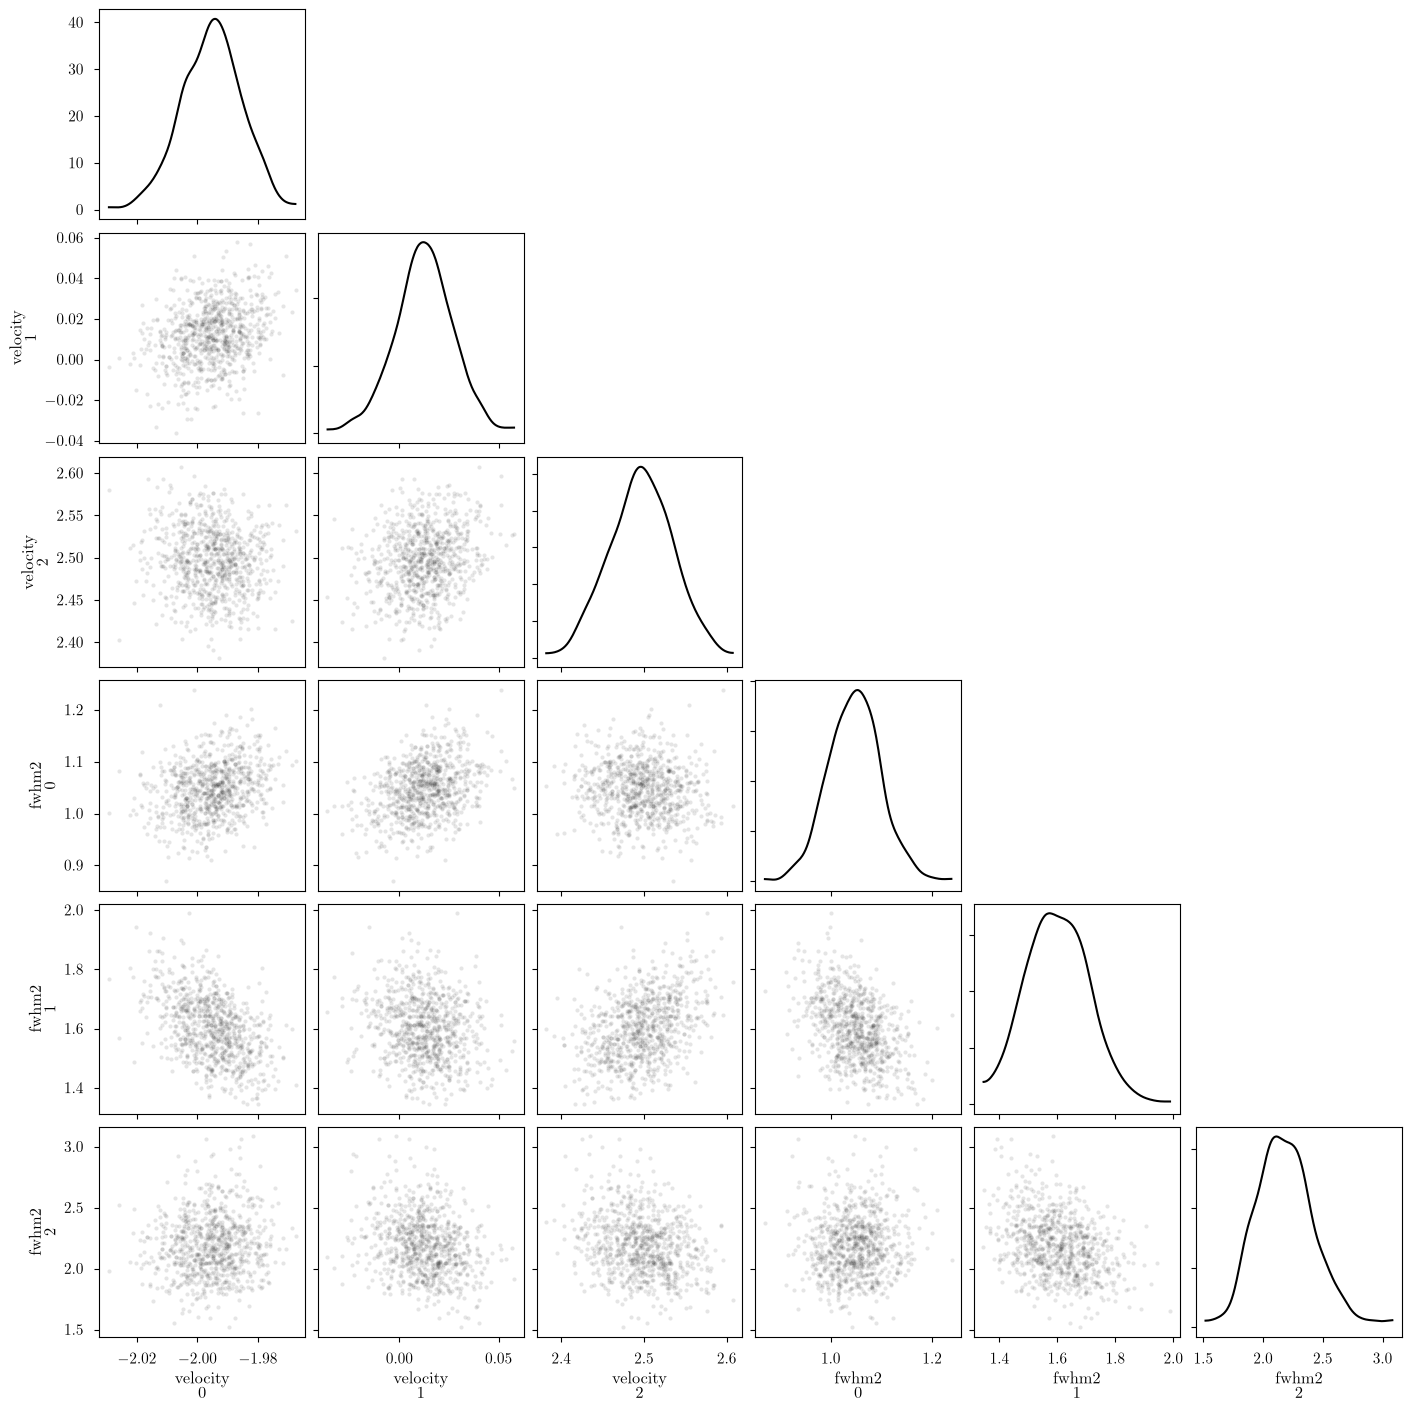

In [28]:
_ = plot_pair(
    model.trace.solution_0.sel(draw=slice(None, None, 10)), # samples
    ["velocity", "fwhm2"], # var_names to plot
    combine_dims=None, # do not concatenate clouds
    kind="scatter", # plot type
)

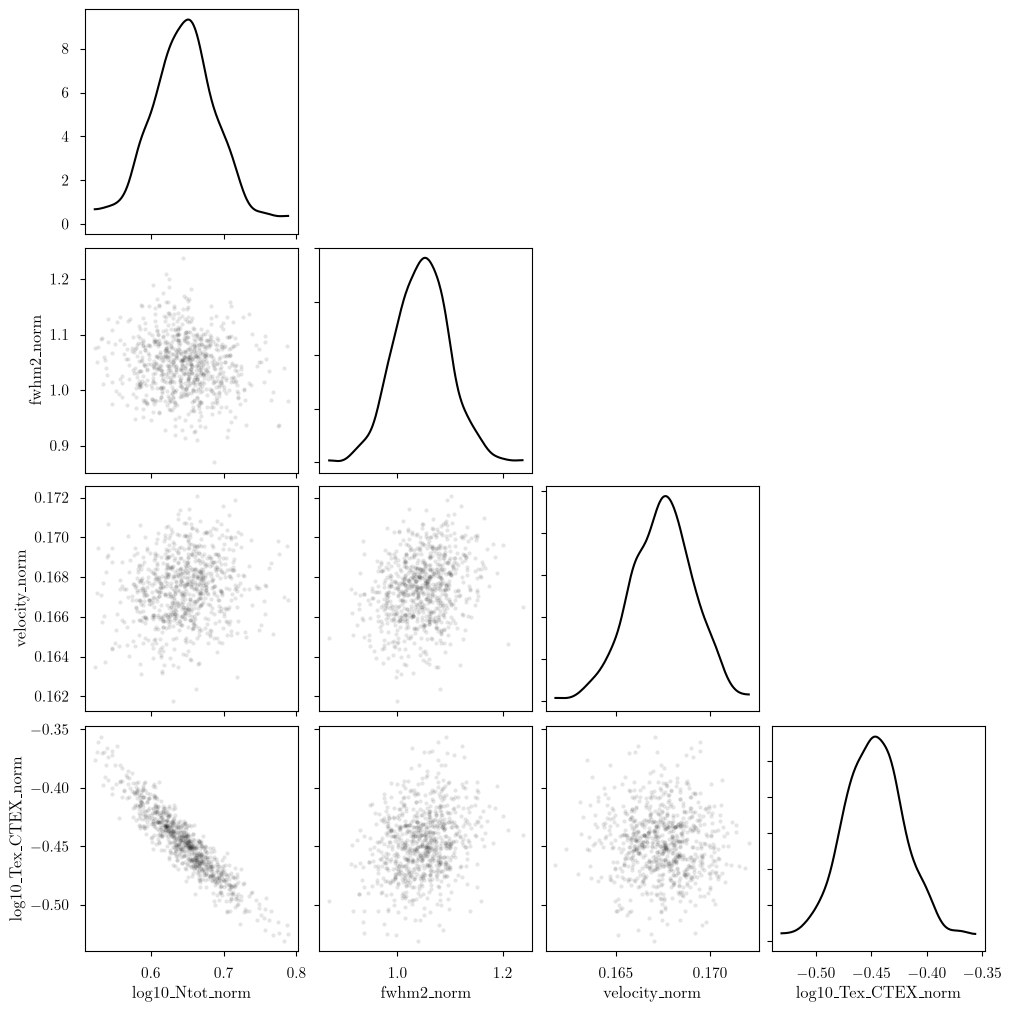

In [29]:
_ = plot_pair(
    model.trace.solution_0.sel(cloud=0, draw=slice(None, None, 10)), # samples
    var_names, # var_names to plot
    kind="scatter", # plot type
)

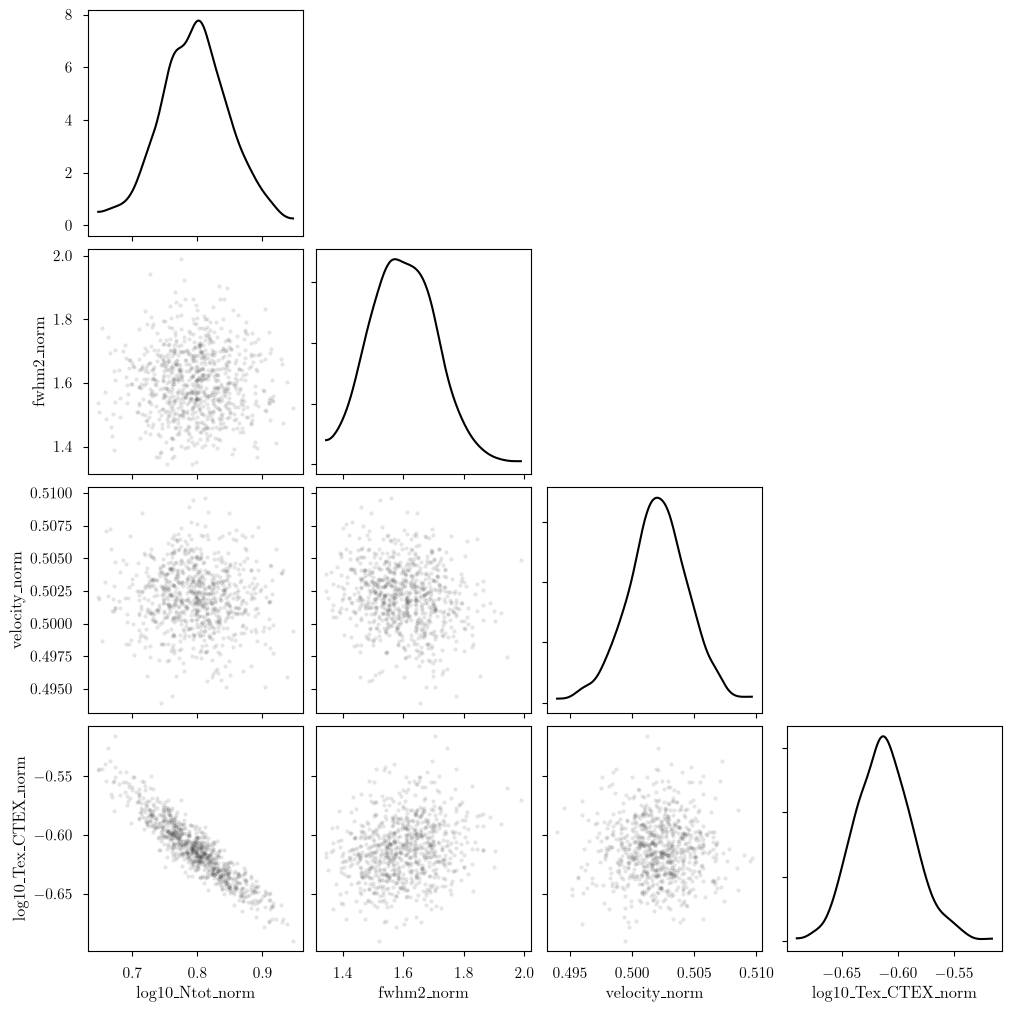

In [30]:
_ = plot_pair(
    model.trace.solution_0.sel(cloud=1, draw=slice(None, None, 10)), # samples
    var_names, # var_names to plot
    kind="scatter", # plot type
)

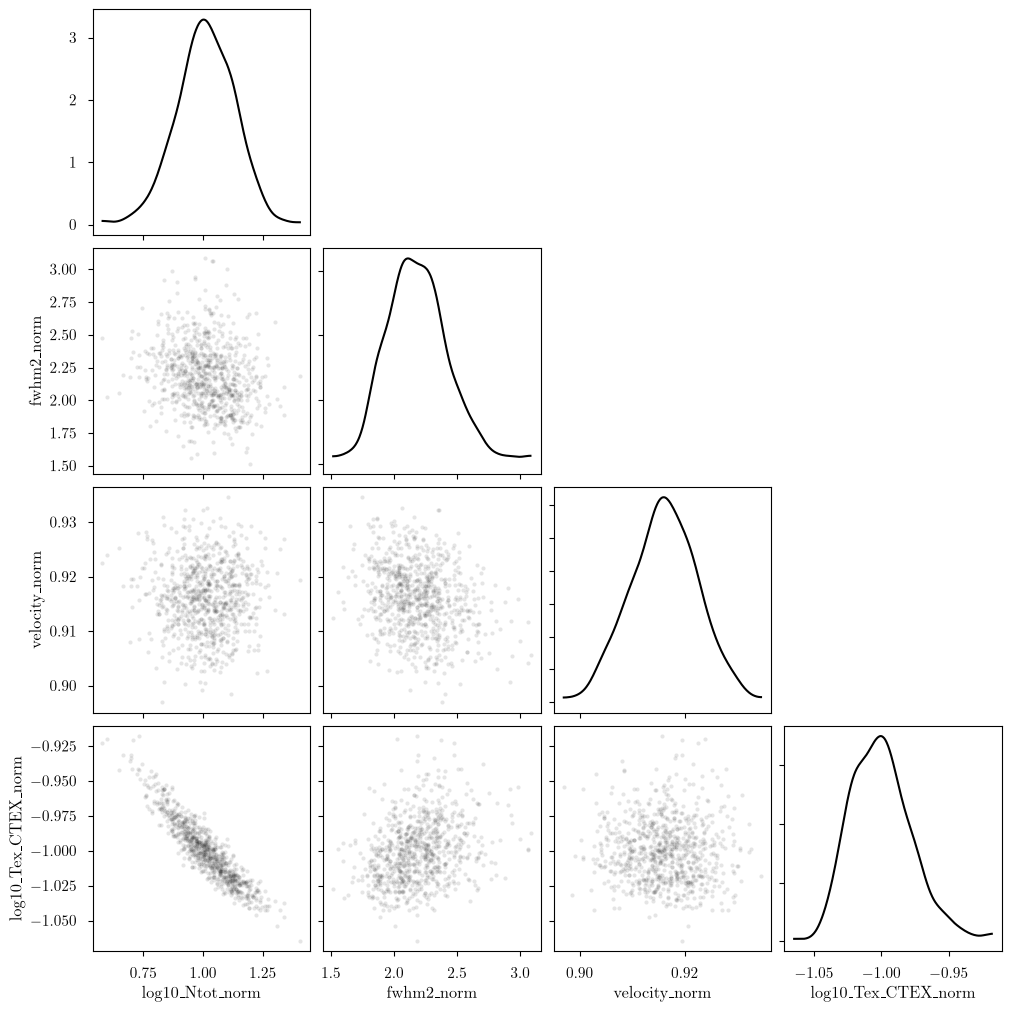

In [31]:
_ = plot_pair(
    model.trace.solution_0.sel(cloud=2, draw=slice(None, None, 10)), # samples
    var_names, # var_names to plot
    kind="scatter", # plot type
)

['log10_Ntot', 'fwhm2', 'velocity', 'log10_Tex_CTEX', 'Tex', 'tau_total']


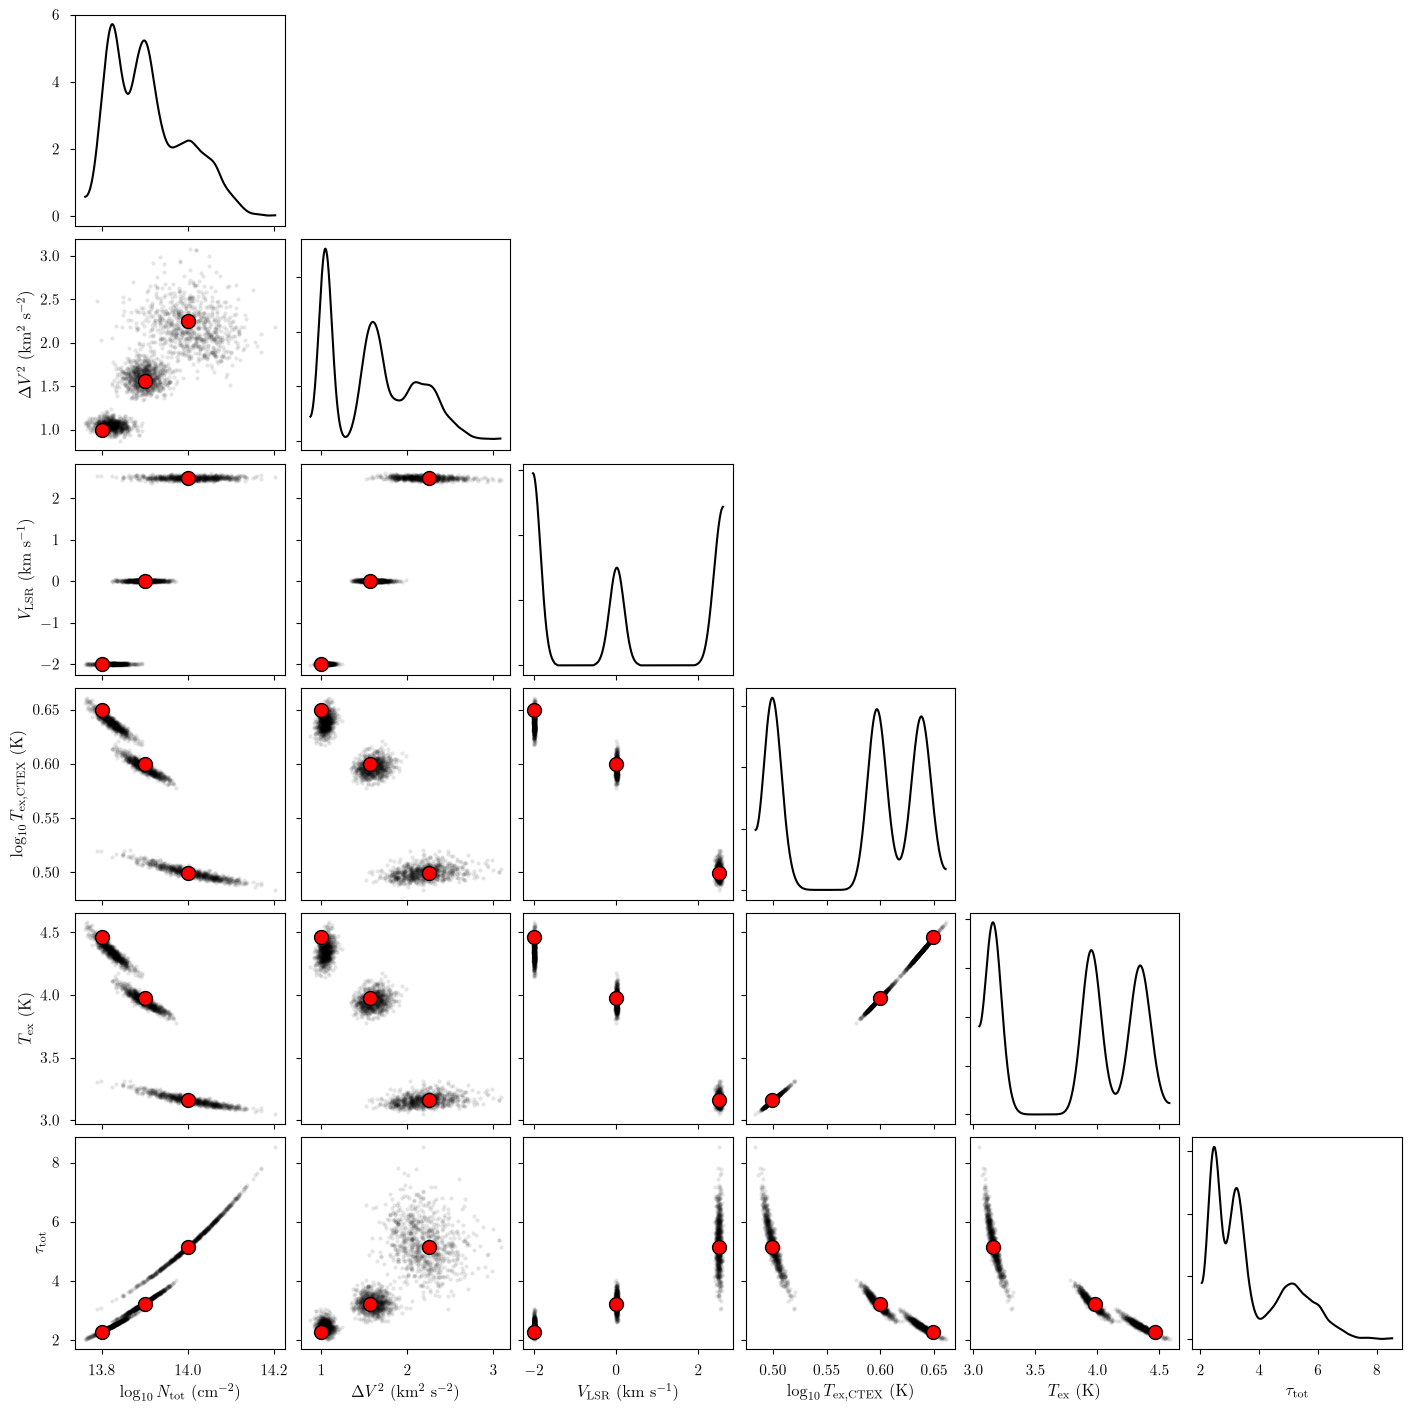

In [32]:
var_names = [
    param for param in model.cloud_deterministics + [p for p in model.cloud_freeRVs if "_norm" not in p]
    if not set(model.model.named_vars_to_dims[param]).intersection(set(["transition", "state"]))
]
print(var_names)

_ = plot_pair(
    model.trace.solution_0.sel(draw=slice(None, None, 10)), # samples
    var_names, # var_names to plot
    combine_dims=["cloud"], # concatenate clouds
    labeller=model.labeller, # label manager
    kind="scatter", # plot type
    reference_values=sim_params, # truths
)

In [33]:
# identify simulation cloud corresponding to each posterior cloud
sim_cloud_map = {}
for i in range(n_clouds):
    posterior_velocity = model.trace.solution_0['velocity'].sel(cloud=i).data.mean()
    match = np.argmin(np.abs(sim_params["velocity"] - posterior_velocity))
    sim_cloud_map[i] = match
sim_cloud_map

{0: np.int64(0), 1: np.int64(1), 2: np.int64(2)}

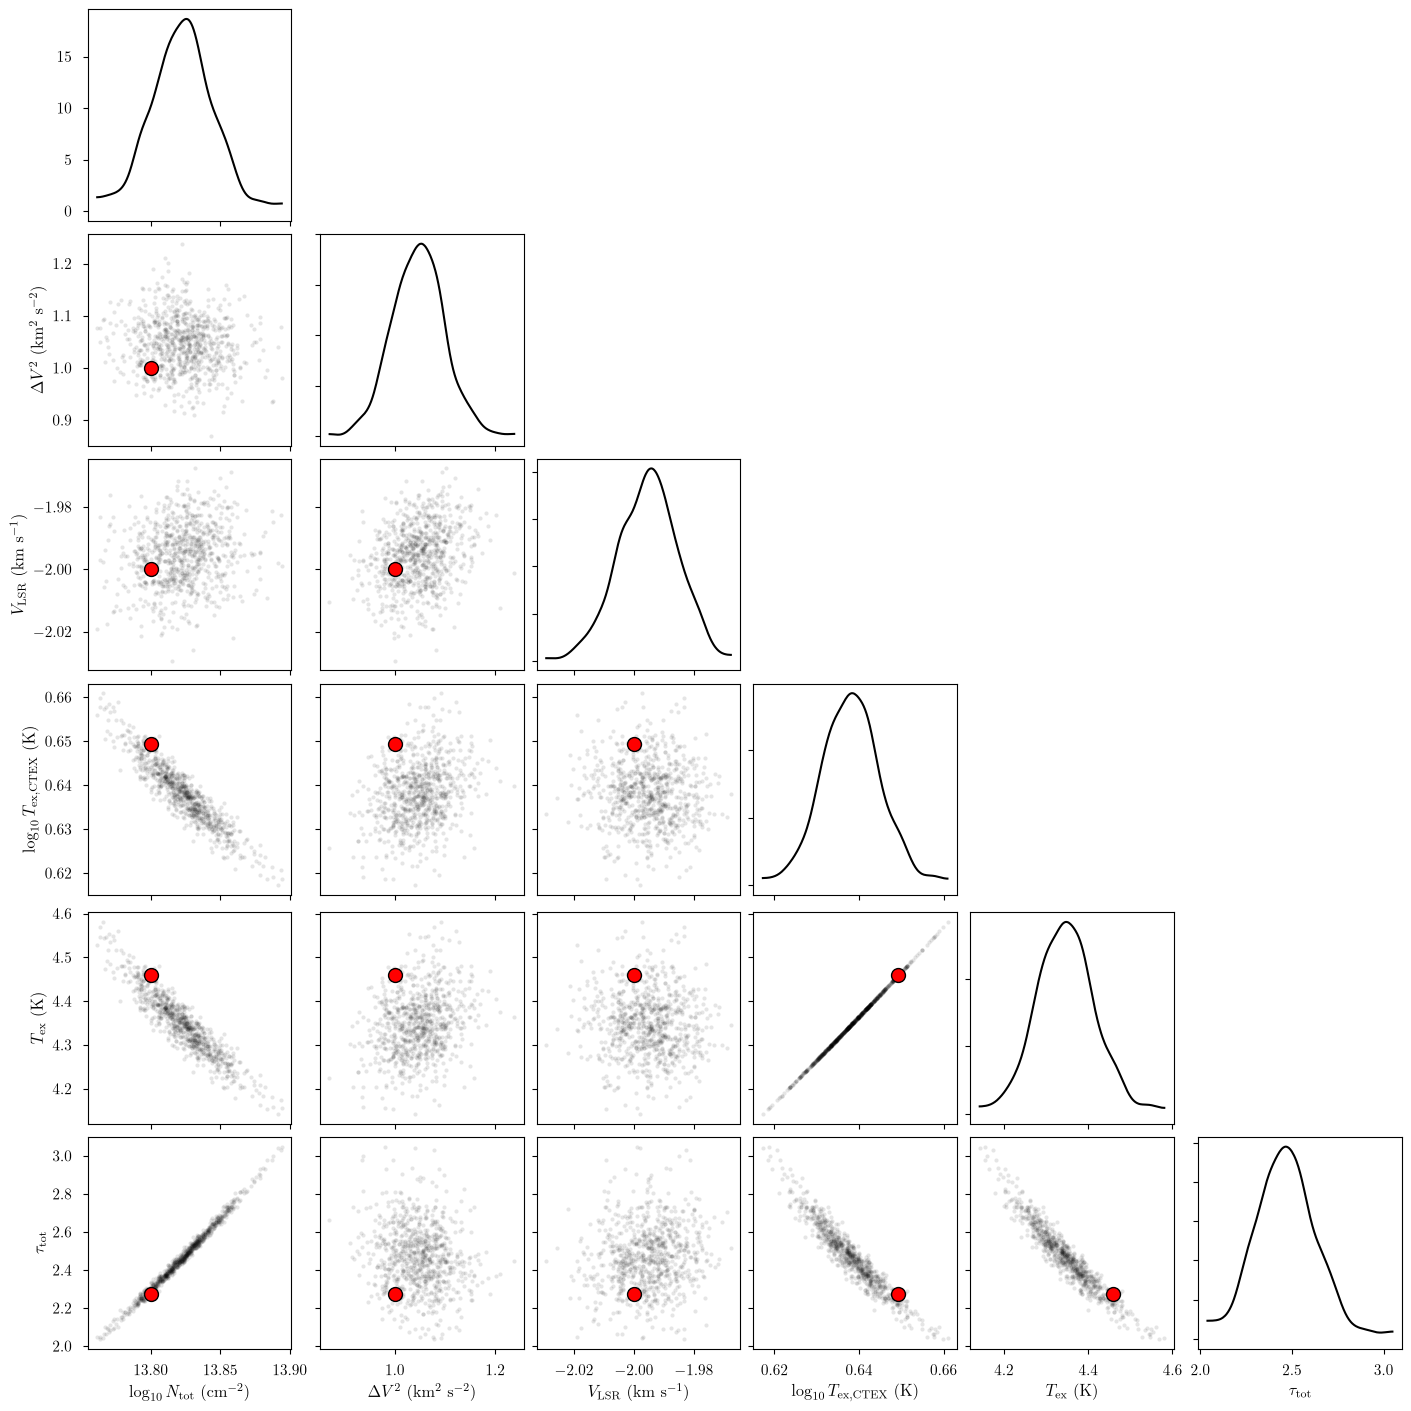

In [34]:
cloud = 0

# subset of sim_params
my_sim_params = {}
for var_name in var_names:
    my_sim_params[var_name] = sim_params[var_name][sim_cloud_map[cloud]]

_ = plot_pair(
    model.trace.solution_0.sel(cloud=cloud, draw=slice(None, None, 10)), # samples
    var_names, # var_names to plot
    labeller=model.labeller, # label manager
    kind="scatter", # plot type
    reference_values=my_sim_params, # truths
)

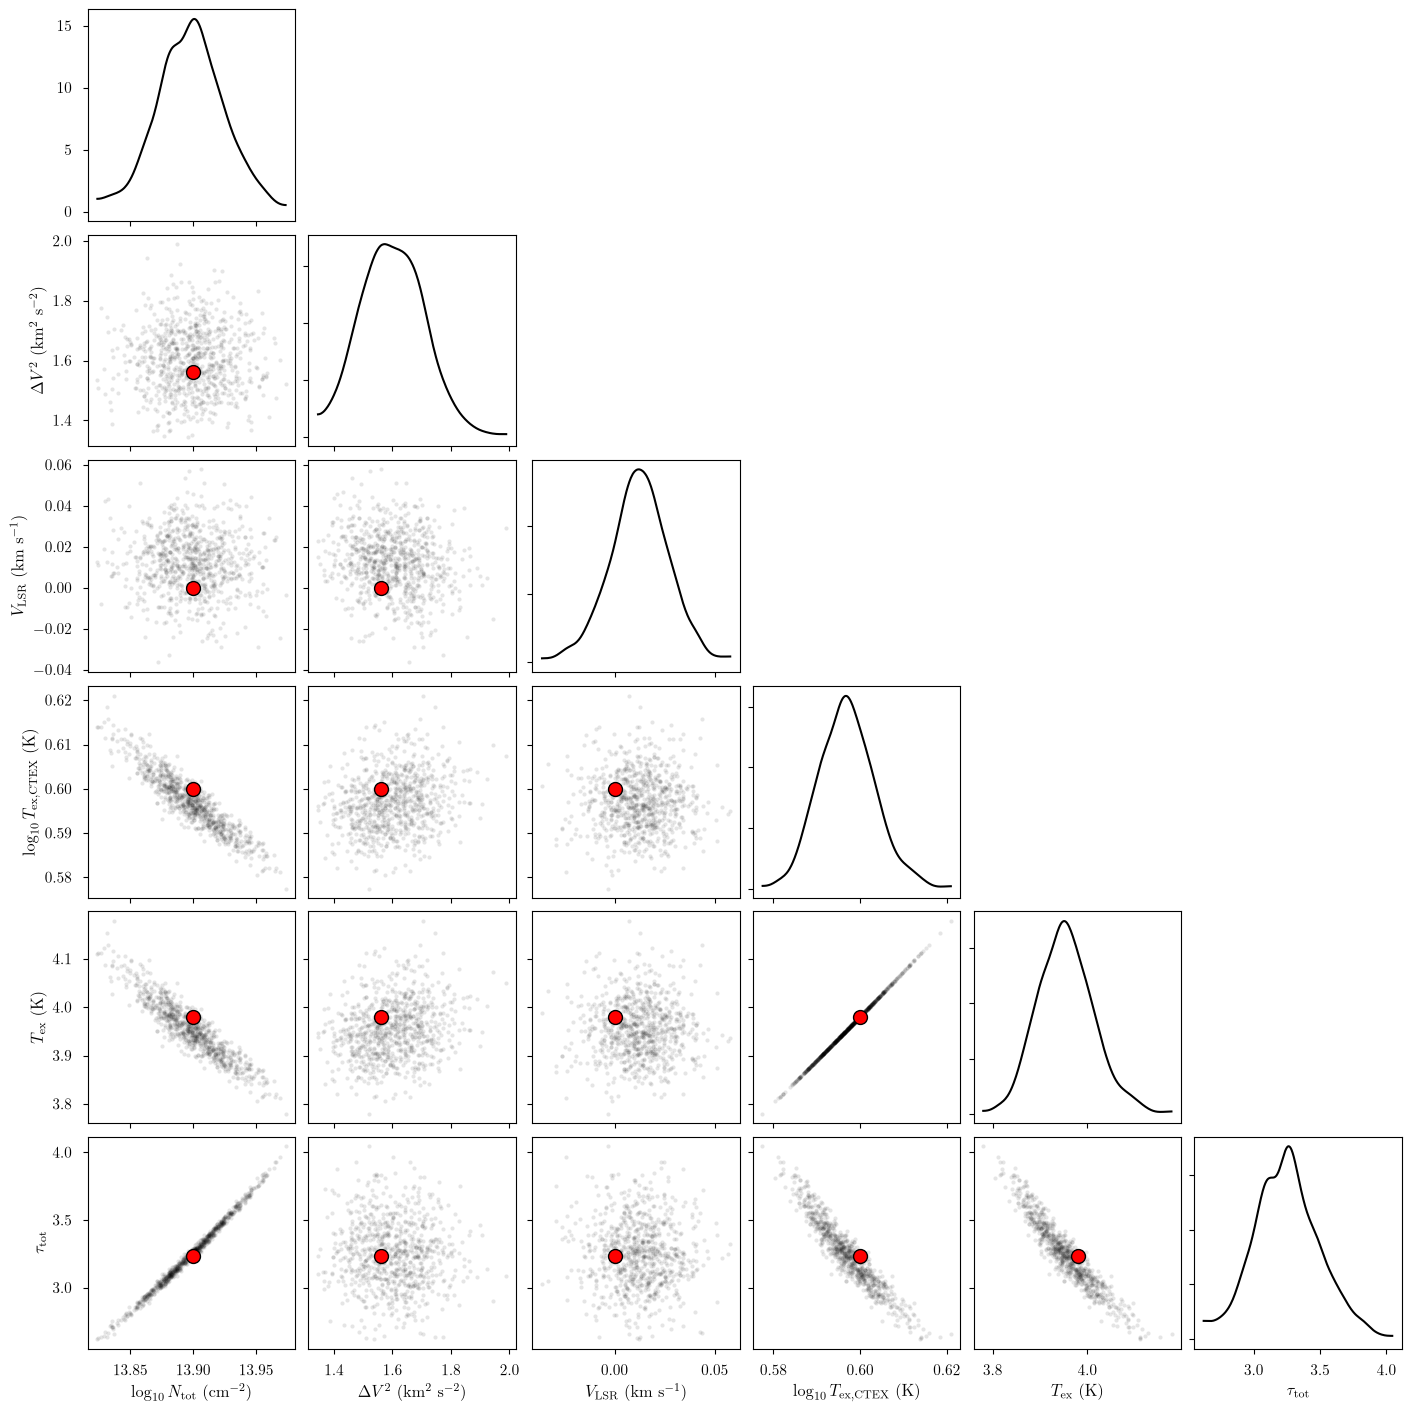

In [35]:
cloud = 1

# subset of sim_params
my_sim_params = {}
for var_name in var_names:
    my_sim_params[var_name] = sim_params[var_name][sim_cloud_map[cloud]]
    
_ = plot_pair(
    model.trace.solution_0.sel(cloud=cloud, draw=slice(None, None, 10)), # samples
    var_names, # var_names to plot
    labeller=model.labeller, # label manager
    kind="scatter", # plot type
    reference_values=my_sim_params, # truths
)

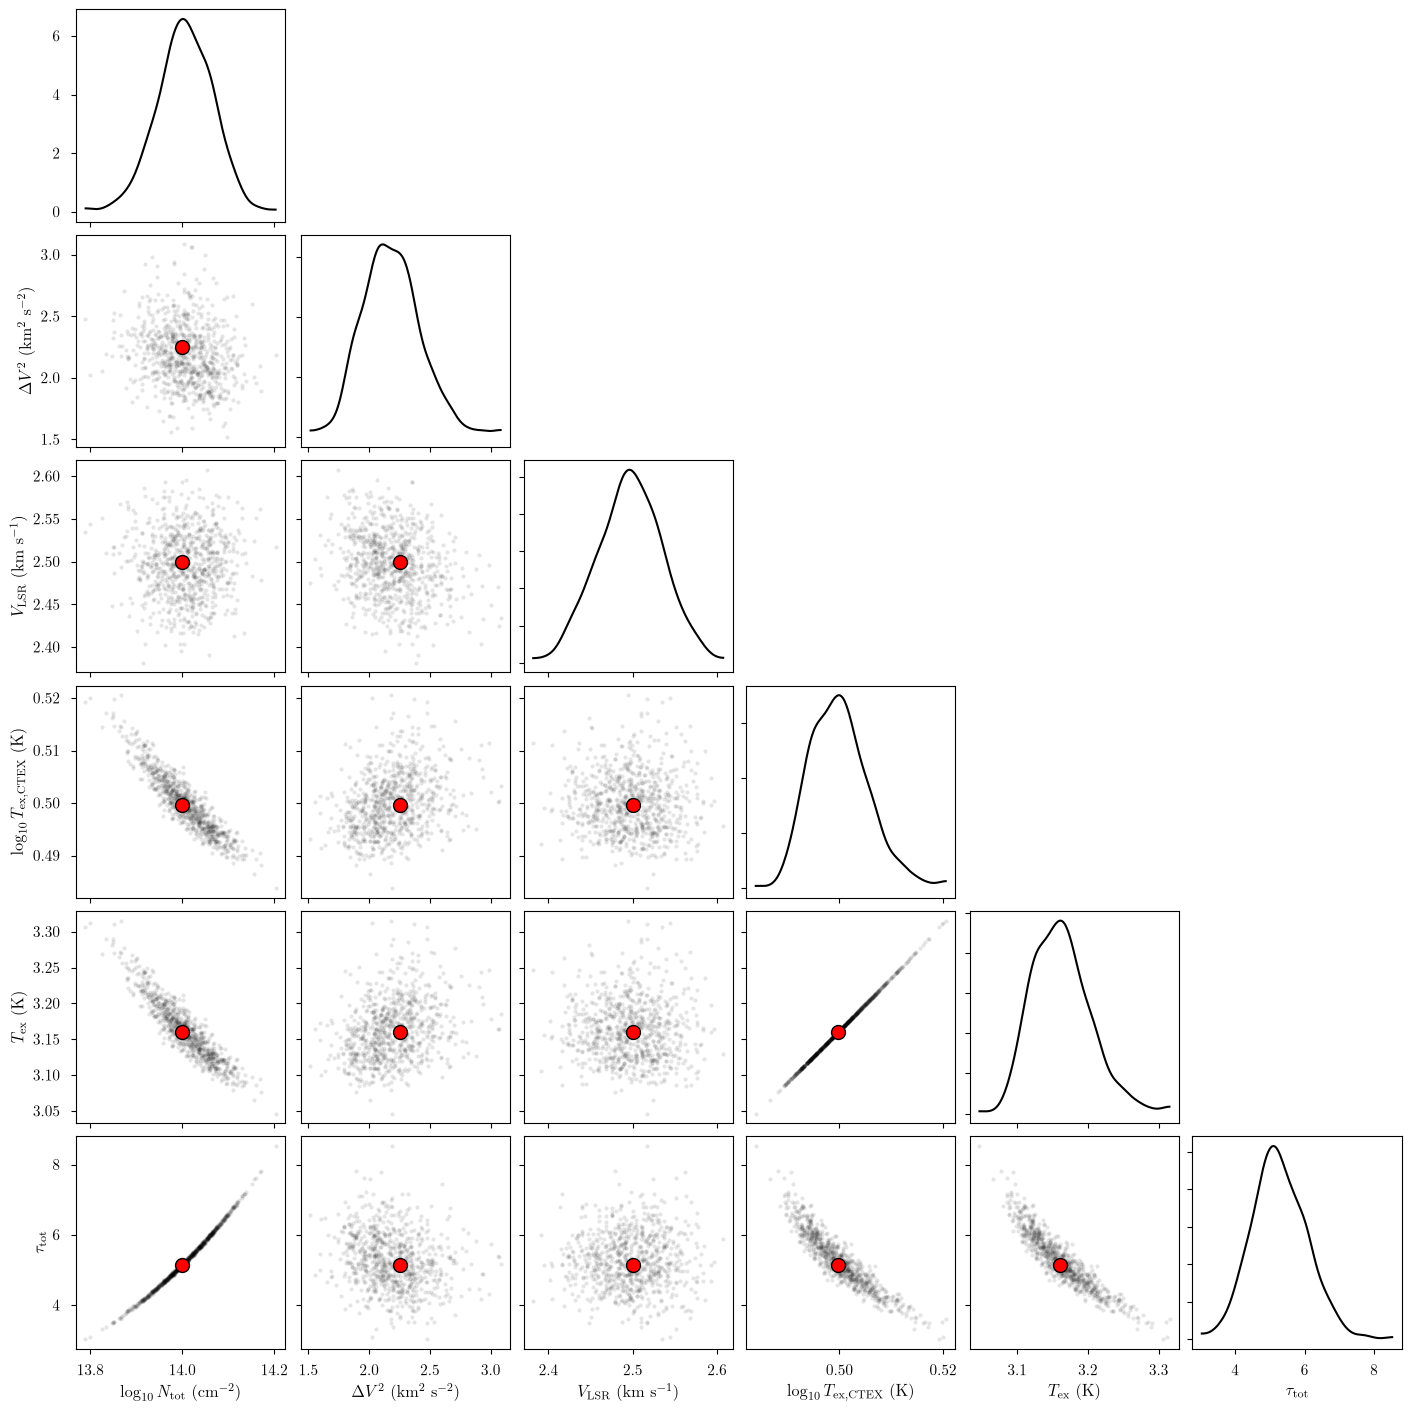

In [36]:
cloud = 2

# subset of sim_params
my_sim_params = {}
for var_name in var_names:
    my_sim_params[var_name] = sim_params[var_name][sim_cloud_map[cloud]]
    
_ = plot_pair(
    model.trace.solution_0.sel(cloud=cloud, draw=slice(None, None, 10)), # samples
    var_names, # var_names to plot
    labeller=model.labeller, # label manager
    kind="scatter", # plot type
    reference_values=my_sim_params, # truths
)

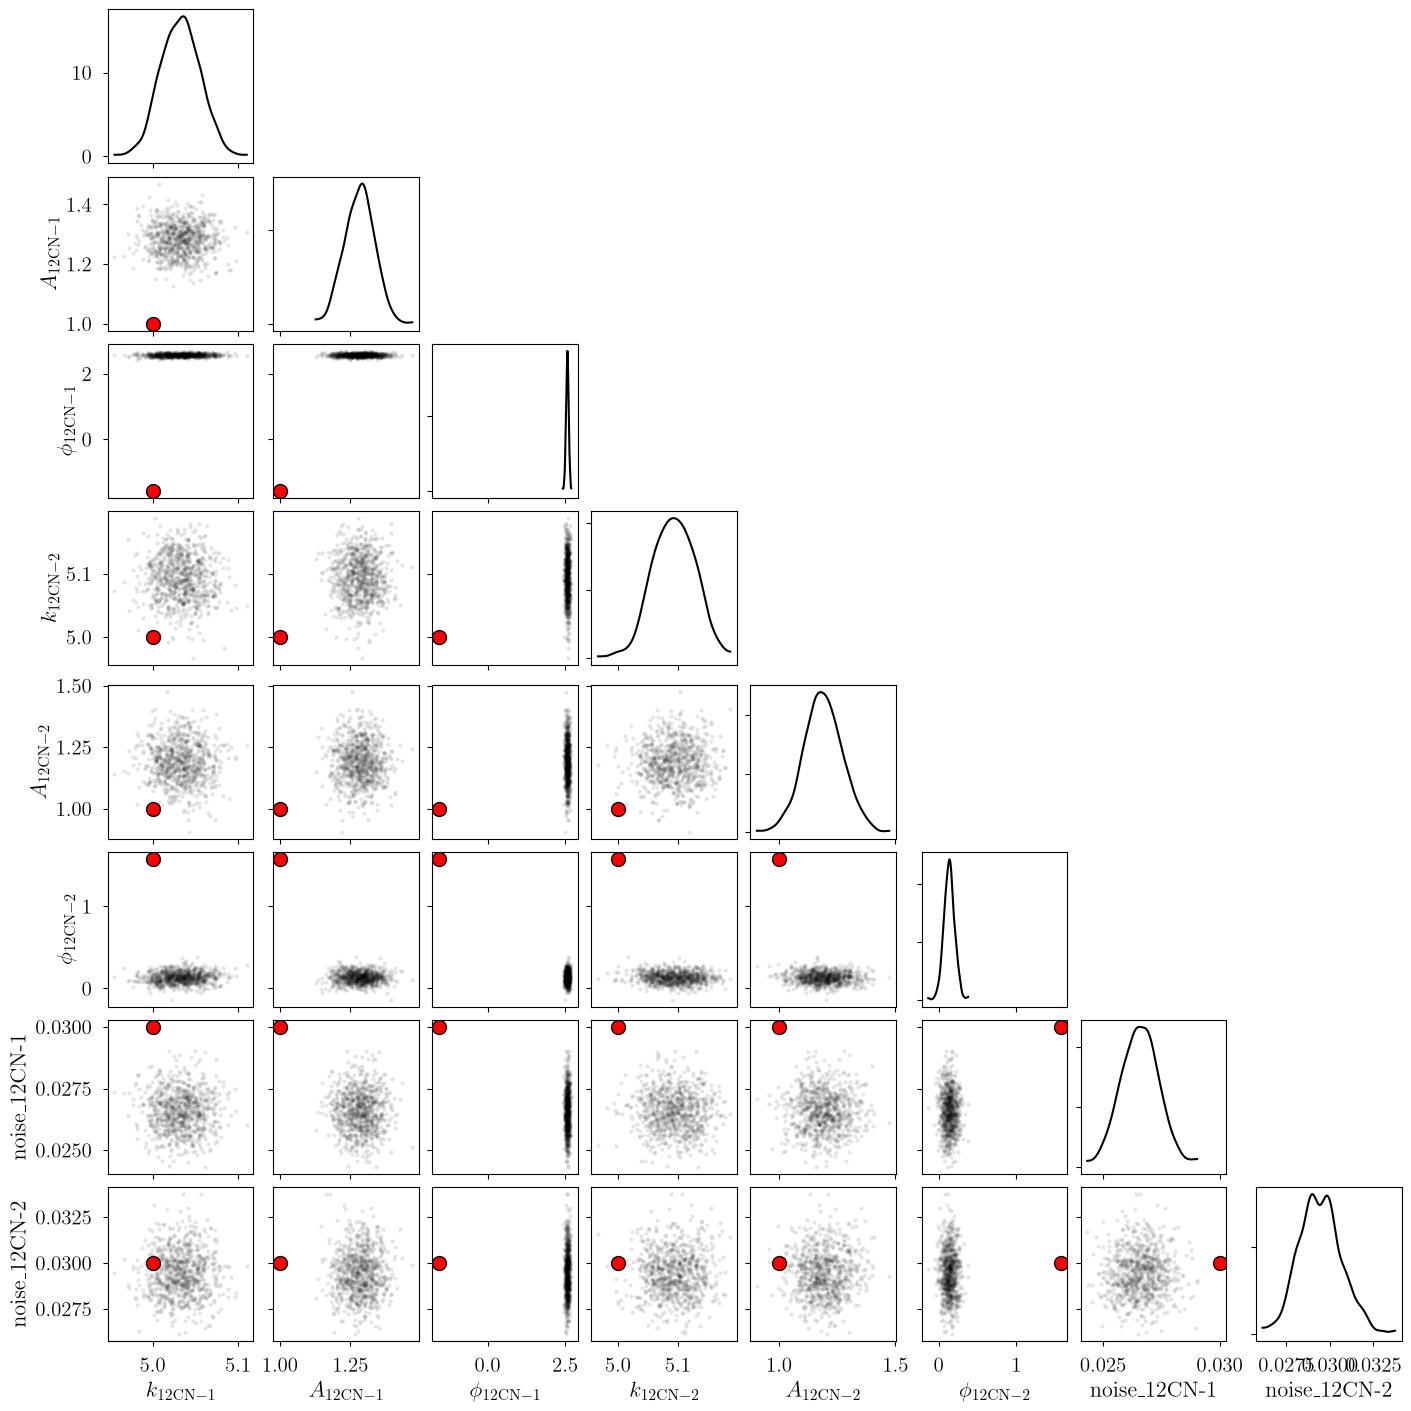

In [38]:
var_names = model.hyper_deterministics + [var_name for var_name in model.hyper_freeRVs if "noise" in var_name]

axes = plot_pair(
    model.trace.solution_0.sel(draw=slice(None, None, 10)), # samples
    var_names, # var_names to plot
    labeller=model.labeller, # label manager
    kind="scatter", # plot type
    reference_values=sim_params, # truths
)
axes.ravel()[0].figure.set_size_inches(14, 14)

In [39]:
point_stats = az.summary(model.trace.solution_0, kind='stats')
print("BIC:", model.bic())
display(point_stats)

BIC: -3547.2996990857464


,mean,sd,hdi_3%,hdi_97%
baseline_12CN-1_norm[0],-0.043,0.039,-0.117,0.028
baseline_12CN-2_norm[0],-0.006,0.061,-0.117,0.109
ripple_12CN-1_cos_amplitude_norm,0.694,0.055,0.591,0.798
ripple_12CN-1_sin_amplitude_norm,-1.081,0.054,-1.180,-0.979
ripple_12CN-2_cos_amplitude_norm,0.157,0.083,0.006,0.316
ripple_12CN-2_sin_amplitude_norm,1.173,0.085,1.012,1.332
log10_Ntot_norm[0],0.647,0.043,0.567,0.728
log10_Ntot_norm[1],0.799,0.052,0.698,0.894
log10_Ntot_norm[2],1.014,0.121,0.789,1.240
log10_Tex_CTEX_norm[0],-0.448,0.028,-0.497,-0.394
